### Import library

In [65]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Load Titanic dataset

In [56]:
print("="*70)
print("STACKING ENSEMBLE: TITANIC SURVIVAL PREDICTION")
print("="*70)

# Load data from seaborn or sklearn
try:
    import seaborn as sns
    titanic = sns.load_dataset('titanic')
except:
    # Fallback to loading from URL
    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
    titanic = pd.read_csv(url)

print(f"\nDataset shape: {titanic.shape}")
print(f"\nRandom samples few rows:")
print(titanic.sample(5))

STACKING ENSEMBLE: TITANIC SURVIVAL PREDICTION

Dataset shape: (891, 15)

Random samples few rows:
     survived  pclass   sex   age  sibsp  parch    fare embarked  class  who  \
138         0       3  male  16.0      0      0  9.2167        S  Third  man   
753         0       3  male  23.0      0      0  7.8958        S  Third  man   
287         0       3  male  22.0      0      0  7.8958        S  Third  man   
363         0       3  male  35.0      0      0  7.0500        S  Third  man   
267         1       3  male  25.0      1      0  7.7750        S  Third  man   

     adult_male deck  embark_town alive  alone  
138        True  NaN  Southampton    no   True  
753        True  NaN  Southampton    no   True  
287        True  NaN  Southampton    no   True  
363        True  NaN  Southampton    no   True  
267        True  NaN  Southampton   yes  False  


# Data Preprocessing

In [26]:
# Select relevant features
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

# Create a clean dataset
df = titanic[features + [target]].copy()

In [27]:
# Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Encode categorical variables
le_sex = LabelEncoder()
le_embarked = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])
df['embarked'] = le_embarked.fit_transform(df['embarked'])


In [28]:
# Separate features and target
X = df[features].values
y = df[target].values

In [29]:
# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [30]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Survival rate (train): {y_train.mean():.2%}")
print(f"Survival rate (test): {y_test.mean():.2%}")

Training samples: 712
Testing samples: 179
Survival rate (train): 38.34%
Survival rate (test): 38.55%


# Stacking Implementation (Level 0)

### Define base models

In [31]:
base_models = {
    'rf': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'gb': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    'svc': SVC(probability=True, kernel='rbf', random_state=42),
    'mlp': MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42)
}

### Generate out-of-fold predictions

In [32]:
n_folds = 5
kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Storage for out-of-fold predictions
oof_predictions = np.zeros((X_train.shape[0], len(base_models)))
test_predictions = np.zeros((X_test.shape[0], len(base_models)))

### Generating Out-of-Fold Predictions

In [41]:
for model_idx, (model_name, model) in enumerate(base_models.items()):
    print(f"\nProcessing {model_name.upper()}:")
    
    # Storage for test predictions from each fold
    test_pred_folds = np.zeros((X_test.shape[0], n_folds))

    # kfold.split(...):     This is a generator. It doesn't return the actual data; it returns the indices (the row numbers). 
    #                       If you have 100 rows, it might say: "For Fold 1, use rows 0–79 for training and 80–99 for validation."
    # train_idx / val_idx:  These are arrays of integers. For a 5-fold split, train_idx will contain 80% of your row numbers, 
    #                       and val_idx will contain the remaining 20%.
    # fold_idx:             This simply tracks which fold you are currently on (0, 1, 2, 3, or 4).
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
        # Split data
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # Train model on this fold
        model.fit(X_fold_train, y_fold_train)
        
        # Predict on validation fold (out-of-fold prediction)
        oof_predictions[val_idx, model_idx] = model.predict_proba(X_fold_val)[:, 1]
        
        # Predict on test set
        test_pred_folds[:, fold_idx] = model.predict_proba(X_test)[:, 1]
        
        # Validation score for this fold
        fold_score = roc_auc_score(y_fold_val, oof_predictions[val_idx, model_idx])
        fold_acc = accuracy_score(y_fold_val, (oof_predictions[val_idx, model_idx] > 0.5).astype(int))
        fold_precision = precision_score(y_fold_val, (oof_predictions[val_idx, model_idx] > 0.5).astype(int))
        print(f"  Fold {fold_idx + 1}: ROC-AUC = {fold_score:.4f}, Accuracy = {fold_acc:.4f}, Precision = {fold_precision:.4f}")

    # Average test predictions across folds
    test_predictions[:, model_idx] = test_pred_folds.mean(axis=1)
    
    # Overall out-of-fold score
    oof_score = roc_auc_score(y_train, oof_predictions[:, model_idx])
    oof_acc = accuracy_score(y_train, (oof_predictions[:, model_idx] > 0.5).astype(int))
    print(f"  Overall OOF - ROC-AUC: {oof_score:.4f}, Accuracy: {oof_acc:.4f}")


Processing RF:
  Fold 1: ROC-AUC = 0.8955, Accuracy = 0.8462, Precision = 0.8367
  Fold 2: ROC-AUC = 0.8540, Accuracy = 0.8112, Precision = 0.8043
  Fold 3: ROC-AUC = 0.9092, Accuracy = 0.8310, Precision = 0.8605
  Fold 4: ROC-AUC = 0.8696, Accuracy = 0.8028, Precision = 0.7826
  Fold 5: ROC-AUC = 0.8642, Accuracy = 0.8028, Precision = 0.8250
  Overall OOF - ROC-AUC: 0.8746, Accuracy: 0.8188

Processing GB:
  Fold 1: ROC-AUC = 0.8958, Accuracy = 0.8531, Precision = 0.8400
  Fold 2: ROC-AUC = 0.8530, Accuracy = 0.7972, Precision = 0.7600
  Fold 3: ROC-AUC = 0.9097, Accuracy = 0.8732, Precision = 0.9512
  Fold 4: ROC-AUC = 0.8814, Accuracy = 0.7746, Precision = 0.6964
  Fold 5: ROC-AUC = 0.9018, Accuracy = 0.8310, Precision = 0.8409
  Overall OOF - ROC-AUC: 0.8841, Accuracy: 0.8258

Processing SVC:
  Fold 1: ROC-AUC = 0.8478, Accuracy = 0.8392, Precision = 0.8077
  Fold 2: ROC-AUC = 0.8277, Accuracy = 0.8112, Precision = 0.8043
  Fold 3: ROC-AUC = 0.9094, Accuracy = 0.8662, Precision = 

### Evaluate base models

In [43]:
print("\nBase Model Performance Summary:")
print("-" * 70)
print(f"{'Model':<10} {'OOF ROC-AUC':<15} {'Test ROC-AUC':<15} {'Test Accuracy':<15}")
print("-" * 70)
for model_idx, model_name in enumerate(base_models.keys()):
    oof_score = roc_auc_score(y_train, oof_predictions[:, model_idx])
    test_score = roc_auc_score(y_test, test_predictions[:, model_idx])
    test_acc = accuracy_score(y_test, (test_predictions[:, model_idx] > 0.5).astype(int))
    print(f"{model_name.upper():<10} {oof_score:<15.4f} {test_score:<15.4f} {test_acc:<15.4f}")


Base Model Performance Summary:
----------------------------------------------------------------------
Model      OOF ROC-AUC     Test ROC-AUC    Test Accuracy  
----------------------------------------------------------------------
RF         0.8746          0.8441          0.7989         
GB         0.8841          0.8173          0.7989         
SVC        0.8516          0.8447          0.8156         
MLP        0.8359          0.8373          0.7709         


# Train meta-model (Level 1)

In [44]:
meta_model = LogisticRegression(random_state=42, max_iter=1000)
meta_model.fit(oof_predictions, y_train)

# Meta-model feature importance (weights for each base model)
print("\nMeta-Model Learned Weights:")
for model_name, weight in zip(base_models.keys(), meta_model.coef_[0]):
    print(f"  {model_name.upper():5s}: {weight:+.4f}")
print(f"  Intercept: {meta_model.intercept_[0]:+.4f}")


Meta-Model Learned Weights:
  RF   : +1.9484
  GB   : +2.5212
  SVC  : +0.6711
  MLP  : +0.4275
  Intercept: -2.7315


### Step 5: Make final predictions

In [45]:
meta_train_pred = meta_model.predict_proba(oof_predictions)[:, 1]
meta_test_pred = meta_model.predict_proba(test_predictions)[:, 1]

### Step 6: Evaluate stacking ensemble

In [47]:
meta_train_score = roc_auc_score(y_train, meta_train_pred)
meta_test_score = roc_auc_score(y_test, meta_test_pred)
meta_train_acc = accuracy_score(y_train, (meta_train_pred > 0.5).astype(int))
meta_test_acc = accuracy_score(y_test, (meta_test_pred > 0.5).astype(int))
meta_train_precision = precision_score(y_train, (meta_train_pred > 0.5).astype(int))
meta_test_precision = precision_score(y_test, (meta_test_pred > 0.5).astype(int))

print(f"Meta-Model OOF ROC-AUC:   {meta_train_score:.4f}")
print(f"Meta-Model Test ROC-AUC:  {meta_test_score:.4f}")
print(f"Meta-Model OOF Accuracy:  {meta_train_acc:.4f}")
print(f"Meta-Model Test Accuracy: {meta_test_acc:.4f}")
print(f"Meta-Model OOF Precision: {meta_train_precision:.4f}")
print(f"Meta-Model Test Precision: {meta_test_precision:.4f}")

# Compare with best base model
best_base_idx = np.argmax([roc_auc_score(y_test, test_predictions[:, i]) for i in range(len(base_models))])
best_base_test_score = roc_auc_score(y_test, test_predictions[:, best_base_idx])
best_base_name = list(base_models.keys())[best_base_idx]
improvement = meta_test_score - best_base_test_score

print(f"\nBest Base Model ({best_base_name.upper()}): {best_base_test_score:.4f}")
print(f"Improvement from Stacking: {improvement:+.4f} ({improvement/best_base_test_score*100:+.2f}%)")


Meta-Model OOF ROC-AUC:   0.8843
Meta-Model Test ROC-AUC:  0.8487
Meta-Model OOF Accuracy:  0.8174
Meta-Model Test Accuracy: 0.8101
Meta-Model OOF Precision: 0.8017
Meta-Model Test Precision: 0.8302

Best Base Model (SVC): 0.8447
Improvement from Stacking: +0.0041 (+0.48%)


### Compare with simple averaging

In [52]:
avg_test_pred = test_predictions.mean(axis=1)
avg_test_score = roc_auc_score(y_test, avg_test_pred)
avg_test_acc = accuracy_score(y_test, (avg_test_pred > 0.5).astype(int))
avg_test_precision = precision_score(y_test, (avg_test_pred > 0.5).astype(int))

print(f"{'Simple Average ROC-AUC':<25} {avg_test_score:7.4f}")
print(f"{'Simple Average Accuracy':<25} {avg_test_acc:7.4f}")
print(f"{'Simple Average Precision':<25} {avg_test_precision:7.4f}")
print(f"{'Stacking ROC-AUC':<25} {meta_test_score:7.4f}")
print(f"{'Stacking Accuracy':<25} {meta_test_acc:7.4f}")
print(f"{'Stacking Precision':<25} {meta_test_precision:7.4f}")
print(f"{'Advantage of Stacking':<25} {meta_test_score - avg_test_score:+7.4f}")

Simple Average ROC-AUC     0.8490
Simple Average Accuracy    0.8212
Simple Average Precision   0.8491
Stacking ROC-AUC           0.8487
Stacking Accuracy          0.8101
Stacking Precision         0.8302
Advantage of Stacking     -0.0003


### Visualize predictions

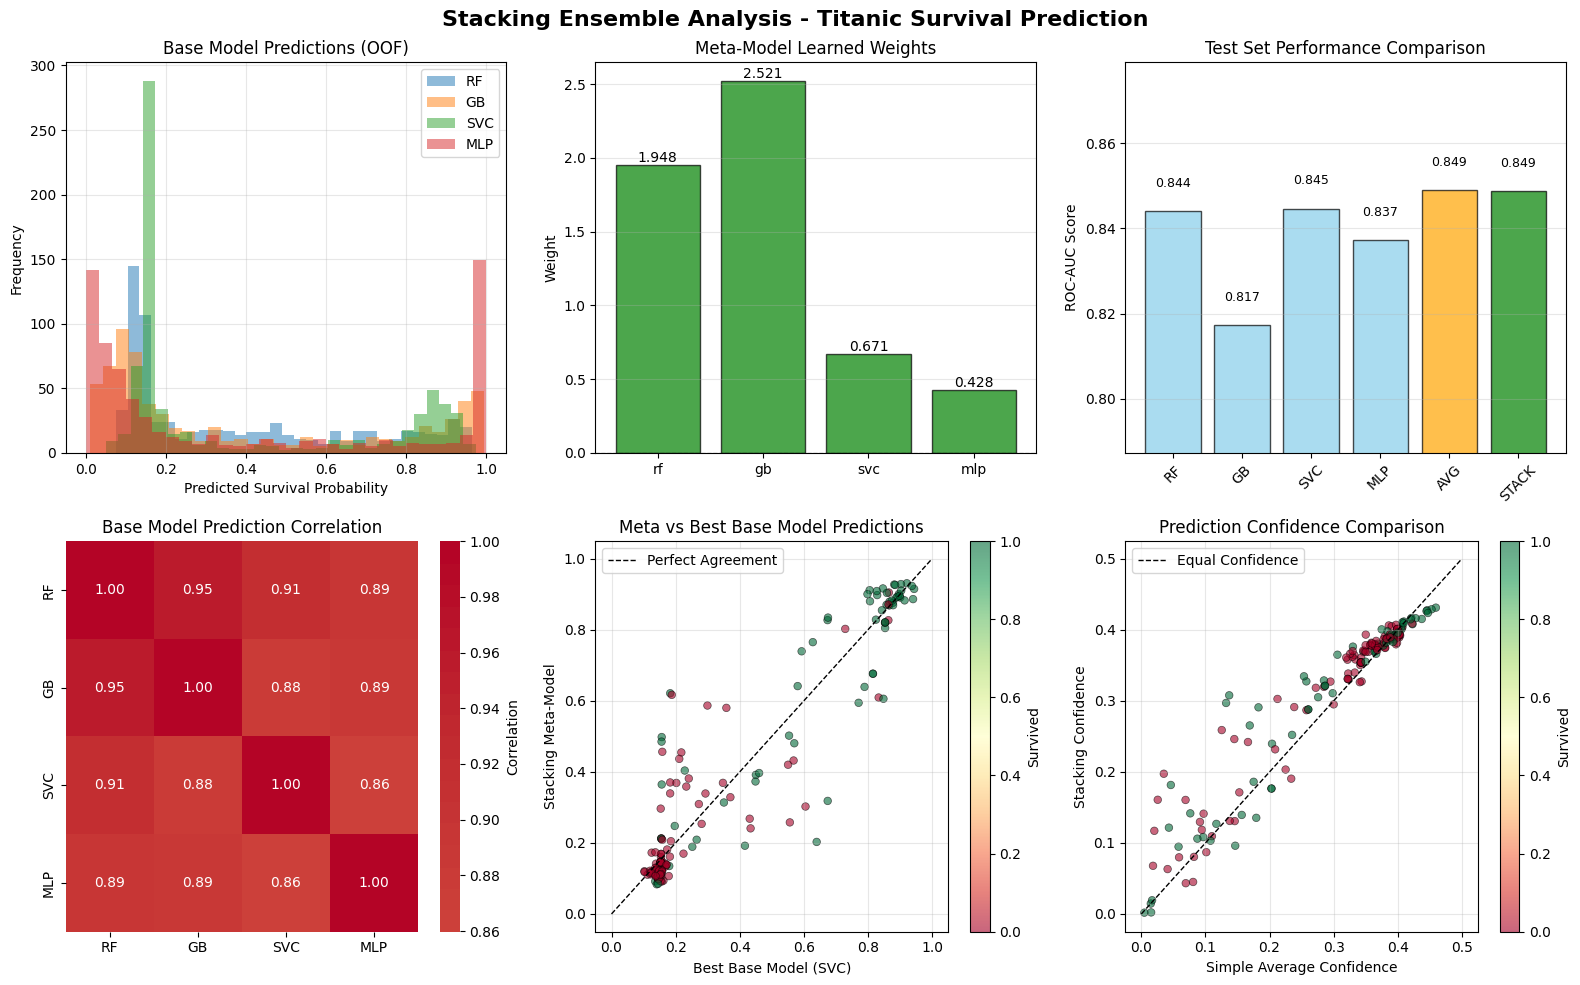

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Stacking Ensemble Analysis - Titanic Survival Prediction', fontsize=16, fontweight='bold')

# Plot 1: Base model OOF predictions distribution
ax = axes[0, 0]
for model_idx, model_name in enumerate(base_models.keys()):
    ax.hist(oof_predictions[:, model_idx], bins=30, alpha=0.5, label=model_name.upper())
ax.set_xlabel('Predicted Survival Probability')
ax.set_ylabel('Frequency')
ax.set_title('Base Model Predictions (OOF)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Meta-model weights
ax = axes[0, 1]
weights = meta_model.coef_[0]
colors = ['green' if w > 0 else 'red' for w in weights]
bars = ax.bar(base_models.keys(), weights, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_ylabel('Weight')
ax.set_title('Meta-Model Learned Weights')
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top')

# Plot 3: Model performance comparison
ax = axes[0, 2]
model_names = [name.upper() for name in base_models.keys()] + ['AVG', 'STACK']
test_scores = [roc_auc_score(y_test, test_predictions[:, i]) 
               for i in range(len(base_models))]
test_scores.extend([avg_test_score, meta_test_score])
colors_bars = ['skyblue'] * len(base_models) + ['orange', 'green']
bars = ax.bar(model_names, test_scores, color=colors_bars, alpha=0.7, edgecolor='black')
ax.set_ylabel('ROC-AUC Score')
ax.set_title('Test Set Performance Comparison')
ax.set_ylim([min(test_scores) - 0.03, max(test_scores) + 0.03])
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
# Add value labels
for bar, score in zip(bars, test_scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Prediction correlation matrix
ax = axes[1, 0]
pred_df = pd.DataFrame(
    test_predictions, 
    columns=[name.upper() for name in base_models.keys()]
)
corr = pred_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            cbar_kws={'label': 'Correlation'})
ax.set_title('Base Model Prediction Correlation')

# Plot 5: Meta vs Best Base predictions
ax = axes[1, 1]
scatter = ax.scatter(test_predictions[:, best_base_idx], meta_test_pred, 
                    alpha=0.6, s=30, c=y_test, cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect Agreement')
ax.set_xlabel(f'Best Base Model ({best_base_name.upper()})')
ax.set_ylabel('Stacking Meta-Model')
ax.set_title('Meta vs Best Base Model Predictions')
ax.grid(True, alpha=0.3)
ax.legend()
plt.colorbar(scatter, ax=ax, label='Survived')

# Plot 6: Prediction confidence comparison
ax = axes[1, 2]
avg_confidence = np.abs(avg_test_pred - 0.5)
meta_confidence = np.abs(meta_test_pred - 0.5)
scatter = ax.scatter(avg_confidence, meta_confidence, alpha=0.6, s=30, 
                    c=y_test, cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax.plot([0, 0.5], [0, 0.5], 'k--', linewidth=1, label='Equal Confidence')
ax.set_xlabel('Simple Average Confidence')
ax.set_ylabel('Stacking Confidence')
ax.set_title('Prediction Confidence Comparison')
ax.grid(True, alpha=0.3)
ax.legend()
plt.colorbar(scatter, ax=ax, label='Survived')

plt.tight_layout()
plt.savefig('stacking_titanic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---

# Using scikit-learn's StackingClassifier

In [55]:
# filepath: sklearn_stacking_example.py
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Define base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
]

# Define meta-model
meta_model = LogisticRegression()

# Create stacking ensemble
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,  # Number of folds for generating OOF predictions
    stack_method='predict_proba',  # Use probabilities
    n_jobs=-1,  # Parallel processing
    verbose=1
)

# Train (handles all the cross-validation internally)
stacking_clf.fit(X_train, y_train)

# Predict
y_pred = stacking_clf.predict(X_test)
y_pred_proba = stacking_clf.predict_proba(X_test)

# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.4s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.4s re

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.64      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.4s remaining:    2.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.4s finished


---


# Credit Card Fraud Detection

**Problem:**
- Highly imbalanced dataset (99.8% legitimate, 0.2% fraud)
- Need high recall (catch frauds) without too many false alarms
- Different fraud patterns require different models

### Step 1: Define diverse base models for different fraud patterns

In [62]:
# Model 1: Random Forest - Good for complex interactions
model_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',  # Handle imbalance
        random_state=42
    ))
])

# Model 2: Gradient Boosting - Sequential pattern learning
model_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

# Model 3: Logistic Regression - Linear patterns and rare events
model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        random_state=42
    ))
])

# Model 4: SVM - Anomaly detection via decision boundary
model_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    ))
])

base_models = {
    'rf': model_rf,
    'gb': model_gb,
    'lr': model_lr,
    'svm': model_svm
}


### Step 2: Generate OOF predictions with SMOTE for each fold

In [63]:
n_folds = 5
kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_predictions = np.zeros((X_train.shape[0], len(base_models)))
test_predictions = np.zeros((X_test.shape[0], len(base_models)))

#### Training Base Models with SMOTE Oversampling

In [67]:
for model_idx, (model_name, model) in enumerate(base_models.items()):
    print(f"\n{model_name.upper()}:")
    
    test_pred_folds = np.zeros((X_test.shape[0], n_folds))
    
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # Apply SMOTE to training fold only
        smote = SMOTE(random_state=42)
        X_fold_train_balanced, y_fold_train_balanced = smote.fit_resample(
            X_fold_train, y_fold_train
        )
        
        # Train on balanced data
        model.fit(X_fold_train_balanced, y_fold_train_balanced)
        
        # Predict on original validation data (not balanced)
        oof_predictions[val_idx, model_idx] = model.predict_proba(X_fold_val)[:, 1]
        test_pred_folds[:, fold_idx] = model.predict_proba(X_test)[:, 1]
        
        # Metrics for this fold
        val_pred_binary = (oof_predictions[val_idx, model_idx] > 0.5).astype(int)
        recall = recall_score(y_fold_val, val_pred_binary)
        precision = precision_score(y_fold_val, val_pred_binary)
        
        print(f"  Fold {fold_idx+1}: Recall={recall:.3f}, Precision={precision:.3f}")
    
    test_predictions[:, model_idx] = test_pred_folds.mean(axis=1)
    
    # Overall OOF metrics
    oof_pred_binary = (oof_predictions[:, model_idx] > 0.5).astype(int)
    oof_recall = recall_score(y_train, oof_pred_binary)
    oof_precision = precision_score(y_train, oof_pred_binary)
    oof_auc = roc_auc_score(y_train, oof_predictions[:, model_idx])
    
    print(f"  OOF: Recall={oof_recall:.3f}, Precision={oof_precision:.3f}, AUC={oof_auc:.3f}")



RF:
  Fold 1: Recall=0.745, Precision=0.759
  Fold 2: Recall=0.745, Precision=0.719
  Fold 3: Recall=0.745, Precision=0.804
  Fold 2: Recall=0.745, Precision=0.719
  Fold 3: Recall=0.745, Precision=0.804
  Fold 4: Recall=0.759, Precision=0.672
  Fold 5: Recall=0.778, Precision=0.824
  OOF: Recall=0.755, Precision=0.752, AUC=0.868

GB:
  Fold 1: Recall=0.764, Precision=0.792
  Fold 4: Recall=0.759, Precision=0.672
  Fold 5: Recall=0.778, Precision=0.824
  OOF: Recall=0.755, Precision=0.752, AUC=0.868

GB:
  Fold 1: Recall=0.764, Precision=0.792
  Fold 2: Recall=0.745, Precision=0.732
  Fold 3: Recall=0.782, Precision=0.782
  Fold 4: Recall=0.759, Precision=0.707
  Fold 2: Recall=0.745, Precision=0.732
  Fold 3: Recall=0.782, Precision=0.782
  Fold 4: Recall=0.759, Precision=0.707
  Fold 5: Recall=0.759, Precision=0.774
  OOF: Recall=0.762, Precision=0.756, AUC=0.865

LR:
  Fold 1: Recall=0.764, Precision=0.677
  Fold 2: Recall=0.691, Precision=0.679
  Fold 3: Recall=0.800, Precision=0.

### Step 3: Train meta-model

In [68]:
# Use Logistic Regression with balanced class weights
meta_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)
meta_model.fit(oof_predictions, y_train)

print("\nMeta-Model Learned Strategy:")
for model_name, weight in zip(base_models.keys(), meta_model.coef_[0]):
    print(f"  {model_name.upper():5s}: {weight:+.4f}")


Meta-Model Learned Strategy:
  RF   : +1.4828
  GB   : +1.4045
  LR   : +1.6553
  SVM  : +0.7061


### Step 4: Final predictions and evaluation

In [69]:
meta_test_pred = meta_model.predict_proba(test_predictions)[:, 1]
meta_test_pred_binary = (meta_test_pred > 0.3).astype(int)  # Lower threshold for fraud

print("Stacking Ensemble Performance on Test Set:")
print("-" * 70)

test_recall = recall_score(y_test, meta_test_pred_binary)
test_precision = precision_score(y_test, meta_test_pred_binary)
test_f1 = f1_score(y_test, meta_test_pred_binary)
test_auc = roc_auc_score(y_test, meta_test_pred)

print(f"Recall:    {test_recall:.3f}  (% of frauds caught)")
print(f"Precision: {test_precision:.3f}  (% of alerts that are real frauds)")
print(f"F1-Score:  {test_f1:.3f}")
print(f"ROC-AUC:   {test_auc:.3f}")


Stacking Ensemble Performance on Test Set:
----------------------------------------------------------------------
Recall:    0.870  (% of frauds caught)
Precision: 0.667  (% of alerts that are real frauds)
F1-Score:  0.755
ROC-AUC:   0.858


### Compare with best base model

In [70]:
best_base_auc = 0
best_base_name = ""

for model_idx, model_name in enumerate(base_models.keys()):
    base_pred_binary = (test_predictions[:, model_idx] > 0.5).astype(int)
    base_auc = roc_auc_score(y_test, test_predictions[:, model_idx])
    
    if base_auc > best_base_auc:
        best_base_auc = base_auc
        best_base_name = model_name

print(f"Best Base Model: {best_base_name.upper()} (AUC = {best_base_auc:.3f})")
print(f"Stacking Ensemble: AUC = {test_auc:.3f}")
print(f"Improvement: {test_auc - best_base_auc:+.3f}")

print("\n" + "="*70)
print("KEY INSIGHT: Stacking combines strengths of different models")
print("  - RF catches complex interaction frauds")
print("  - GB learns sequential fraud patterns")
print("  - LR detects rare linear patterns")
print("  - SVM identifies anomalous transactions")
print("  - Meta-model learns which to trust in each situation")
print("="*70)

Best Base Model: LR (AUC = 0.851)
Stacking Ensemble: AUC = 0.858
Improvement: +0.007

KEY INSIGHT: Stacking combines strengths of different models
  - RF catches complex interaction frauds
  - GB learns sequential fraud patterns
  - LR detects rare linear patterns
  - SVM identifies anomalous transactions
  - Meta-model learns which to trust in each situation
